In [2]:
import pandas as pd
import numpy as np
from scipy.stats import *
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats import weightstats, proportion 

from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import tt_ind_solve_power

In [3]:
df = pd.read_csv('../data/processed/valid_data.csv', parse_dates=['date'])


In [4]:
df.info()
df.head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               108 non-null    datetime64[ns]
 1   publisher_id       108 non-null    int64         
 2   platform           108 non-null    object        
 3   group_name         108 non-null    object        
 4   pageviews          108 non-null    int64         
 5   visible_pageviews  108 non-null    int64         
 6   sessions           108 non-null    int64         
 7   revenue            108 non-null    float64       
 8   sponsord_clicks    108 non-null    int64         
 9   organic_clicks     108 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 8.6+ KB


,date,publisher_id,platform,group_name,pageviews,visible_pageviews,sessions,revenue,sponsord_clicks,organic_clicks
0,2019-03-01,101,Desktop,A,16580,5418,12684,34.5201,300,849
1,2019-03-01,101,Desktop,B,16191,4906,12717,32.9211,268,555
2,2019-03-01,106,Desktop,A,16227,11395,11750,20.1620,601,2425
3,2019-03-01,106,Desktop,B,15060,10369,11967,19.7429,663,1194


In [5]:
dict_platform=dict()
platforms = df['platform'].unique()
for name in platforms:
     #print(name)
     group_stats = (df[df['platform'] == name]
                    .groupby('group_name')
                    .agg({'pageviews':'sum',
                         'visible_pageviews':'sum',
                         'sessions': 'sum',
                         'revenue': 'sum',
                         'sponsord_clicks': 'sum',
                         'organic_clicks': 'sum'})
     ).reset_index()
     group_stats['CTR_paid'] = group_stats['sponsord_clicks'] / group_stats['visible_pageviews']
     group_stats['CTR_organic'] = group_stats['organic_clicks'] / group_stats['visible_pageviews']
     group_stats['RPM'] = group_stats['revenue'] / group_stats['visible_pageviews']*1000
     group_stats['CPC'] = group_stats['revenue'] / group_stats['sponsord_clicks']
     group_stats['RPS'] = group_stats['revenue'] / group_stats['sessions']*1000
     group_stats['Pages_Depth'] = group_stats['pageviews'] / group_stats['sessions']
     # print(group_stats)
     dict_platform[name] = group_stats


In [14]:
dict_platform

{'Desktop':   group_name  pageviews  visible_pageviews  sessions    revenue  \
 0          A     631444             223296    348346  1075.5066   
 1          B     604100             191359    348050  1048.2583   
 
    sponsord_clicks  organic_clicks  CTR_paid  CTR_organic       RPM       CPC  \
 0            11992           42425  0.053704     0.189994  4.816506  0.089685   
 1            11915           19063  0.062265     0.099619  5.477967  0.087978   
 
         RPS  Pages_Depth  
 0  3.087466     1.812692  
 1  3.011804     1.735670  ,
 'Mobile':   group_name  pageviews  visible_pageviews  sessions    revenue  \
 0          A    1007690             240052    580697  1501.9031   
 1          B     977371             210594    579420  1707.2484   
 
    sponsord_clicks  organic_clicks  CTR_paid  CTR_organic       RPM       CPC  \
 0            16032           52784  0.066786     0.219886  6.256574  0.093682   
 1            17643           24599  0.083777     0.116808  8.106824  

In [4]:
# разница между группами B и А по каждой платформе отдельности. для будущих графиков
results = []
for platform, df_group in dict_platform.items():
    # Получаем значения для групп A и B
    A = df_group[df_group['group_name'] == 'A'].iloc[0]
    B = df_group[df_group['group_name'] == 'B'].iloc[0]
    #print(A)
    metrics = ['pageviews', 'visible_pageviews', 'sessions', 'revenue', 
               'sponsord_clicks', 'organic_clicks', 'CTR_paid', 'CTR_organic',
               'RPM', 'CPC', 'RPS', 'Pages_Depth']
    
    # Создаем словарь с изменениями
    change_dict = {'platform': platform}
    for metric in metrics:
        rel_change = ((B[metric] - A[metric]) / A[metric]) * 100
        change_dict[f'{metric}_change_%'] = round(rel_change, 2)
                
    results.append(change_dict)
#print(change_dict)

df_changes = pd.DataFrame(results)
#print(df_changes)

Проверим получили ли мы статистически значимые различия между группами А и В по ключем метрикам:
 - CTR_paid - переход по рекламным ссылкам. Используем взвешаннй t-test, так как платформы имеют разное количество просмотров или же Z-тест для пропорций (проверим оба) 
 - RPM (Revenue per Mille). Используем взвешенный t-test, так как это отношения revenue к увиденным лентам. Revenue - непрерывная величина, так как за просмотр разных реклам имеем разную! прибыль, и количество просмотров очень сильно варируется от издателя к издателю.

In [18]:
# добавляем метрики в каждой платформе и проверяем статистические различия по итогам теста
df['CTR_paid'] = df['sponsord_clicks']  / df['visible_pageviews']
df['RPM'] = df['revenue'] / df['visible_pageviews']*1000
df['RPS'] = df['revenue'] / df['sessions']*1000
df['Pages_per_session'] = df['pageviews'] / df['sessions']
df['CTR_organic'] = df['organic_clicks']  / df['visible_pageviews']

for name, group_stats in dict_platform.items():
    # Проверяем, увеличился ли переход по рекламным ссылкам
    print(name)
    df_platform = df[df['platform'] == name]
    # способ 1. обычный t-test (но с осторожностью, так как мы не учитываем веса)
    # -----
    print(f'''CTR_paid. Конверсия перехода по рекламным ссылкам''')
    gr_A = df_platform[df_platform['group_name'] == 'A']['CTR_paid']
    gr_B = df_platform[df_platform['group_name'] == 'B']['CTR_paid']

    # Н0: конверсия в переход по рекламных ссылкам не изменился. Н1: конверсия в группе В увеличилась
    #t_pvalue1 = ttest_ind(gr_A, gr_B, equal_var = False, alternative='less').pvalue #важно через less, так как сравниваем
    # -----

    #cпособ 2. Взвешенный t-test
    weight_A = df_platform[df_platform['group_name'] == 'A']['visible_pageviews'].values
    weight_B = df_platform[df_platform['group_name'] == 'B']['visible_pageviews'].values
    
    t_stat, t_pvalue2, dif = weightstats.ttest_ind(
        gr_A.values,
        gr_B.values,
        alternative= 'smaller',
        usevar = 'unequal',
        weights = (weight_A, weight_B)
    )

    #способ 3. Z-test 
    # Суммарные данные по группам
    clicks_A = group_stats[group_stats['group_name'] == 'A']['sponsord_clicks'].sum()
    views_A = group_stats[group_stats['group_name'] == 'A']['visible_pageviews'].sum()
    clicks_B = group_stats[group_stats['group_name'] == 'B']['sponsord_clicks'].sum()
    views_B = group_stats[group_stats['group_name'] == 'B']['visible_pageviews'].sum()

    z_stat, z_pvalue = proportion.proportions_ztest(
        count=[clicks_A, clicks_B],
        nobs=[views_A, views_B],
        alternative='smaller'  # для проверки что A < B
    )
    print(f't_pvalue: {t_pvalue2}, z-pvalue: {float(z_pvalue)}')

    # Проверяем увеличилась ли RPM 

    print('RPM. Эффективность монетизации. Увеличение прибыли на 1000 просмотров')
    gr_A = df_platform[df_platform['group_name'] == 'A']['RPM']
    gr_B = df_platform[df_platform['group_name'] == 'B']['RPM']

    weight_A = df_platform[df_platform['group_name'] == 'A']['visible_pageviews'].values
    weight_B = df_platform[df_platform['group_name'] == 'B']['visible_pageviews'].values
    
    t_stat, t_pvalue2, dif = weightstats.ttest_ind(
        gr_A.values,
        gr_B.values,
        alternative= 'two-sided', #'smaller',
        usevar = 'unequal',
        weights = (weight_A, weight_B)
    )
    print(f'p-value: {t_pvalue2}')

    print(f'''CTR_organic. Конверсия перехода по органическим ссылкам''')
    gr_A = df_platform[df_platform['group_name'] == 'A']['organic_clicks']
    gr_B = df_platform[df_platform['group_name'] == 'B']['organic_clicks']

    weight_A = df_platform[df_platform['group_name'] == 'A']['visible_pageviews'].values
    weight_B = df_platform[df_platform['group_name'] == 'B']['visible_pageviews'].values
    
    t_stat, t_pvalue2, dif = weightstats.ttest_ind(
        gr_A.values,
        gr_B.values,
        alternative= 'two-sided',
        usevar = 'unequal',
        weights = (weight_A, weight_B)
    )
    print(f't_pvalue: {t_pvalue2}')
    # Проверяем увеличилась ли RPS 

    print('RPS. Эффективность монетизации. Увеличение прибыли на 1000 сессий')
    gr_A = df_platform[df_platform['group_name'] == 'A']['RPS']
    gr_B = df_platform[df_platform['group_name'] == 'B']['RPS']

    weight_A = df_platform[df_platform['group_name'] == 'A']['sessions'].values
    weight_B = df_platform[df_platform['group_name'] == 'B']['sessions'].values

    t_stat, t_pvalue3, dif = weightstats.ttest_ind(
        gr_A.values,
        gr_B.values,
        alternative='smaller',
        usevar = 'unequal',
        weights = (weight_A, weight_B)
    )
    print(f'p-value: {t_pvalue3}')


Desktop
CTR_paid. Конверсия перехода по рекламным ссылкам
t_pvalue: 0.0, z-pvalue: 2.2039263188958459e-32
RPM. Эффективность монетизации. Увеличение прибыли на 1000 просмотров
p-value: 0.0
CTR_organic. Конверсия перехода по органическим ссылкам
t_pvalue: 0.0
RPS. Эффективность монетизации. Увеличение прибыли на 1000 сессий
p-value: 1.0
Mobile
CTR_paid. Конверсия перехода по рекламным ссылкам


t_pvalue: 0.0, z-pvalue: 3.505924795938159e-104
RPM. Эффективность монетизации. Увеличение прибыли на 1000 просмотров
p-value: 0.0
CTR_organic. Конверсия перехода по органическим ссылкам
t_pvalue: 0.0
RPS. Эффективность монетизации. Увеличение прибыли на 1000 сессий
p-value: 0.0


In [6]:
# разбивка по издательствам Desktop
df_platform_Desktop = df[df['platform'] == 'Desktop']
df_publisher = df_platform_Desktop.groupby(['publisher_id', 'group_name']).agg({'pageviews':'sum', 
                                                                     'visible_pageviews': 'sum',
                                                                     'sponsord_clicks':'sum',
                                                                     'revenue':'sum',
                                                                     'organic_clicks':'sum'}
                                                                     ).reset_index()
df_publisher['RPM'] = df_publisher['revenue'] / df_publisher['visible_pageviews']
df_publisher['CTR_paid'] = df_publisher['sponsord_clicks'] / df_publisher['visible_pageviews']
df_publisher['CTR_organic'] = df_publisher['organic_clicks'] / df_publisher['visible_pageviews']
df_A = df_publisher[df_publisher['group_name'] == 'A']
df_B = df_publisher[df_publisher['group_name'] == 'B']

AB_merge_Desktop = pd.merge(df_A,df_B, how = 'left', on = 'publisher_id', suffixes = ['_A', '_B'])
AB_merge_Desktop

,publisher_id,group_name_A,pageviews_A,visible_pageviews_A,sponsord_clicks_A,revenue_A,organic_clicks_A,RPM_A,CTR_paid_A,CTR_organic_A,group_name_B,pageviews_B,visible_pageviews_B,sponsord_clicks_B,revenue_B,organic_clicks_B,RPM_B,CTR_paid_B,CTR_organic_B
0,101,A,115978,37314,2009,228.8909,6202,0.006134,0.053840,0.166211,B,110960,33480,1811,219.7185,3690,0.006563,0.054092,0.110215
1,106,A,107063,74712,4669,139.8213,15546,0.001871,0.062493,0.208079,B,97565,66122,4680,133.2958,6902,0.002016,0.070778,0.104383
2,111,A,88814,37242,2473,527.0839,4931,0.014153,0.066404,0.132404,B,85462,33420,2386,513.5250,1613,0.015366,0.071394,0.048265
3,123,A,148222,24532,1737,75.9674,4366,0.003097,0.070805,0.177972,B,145580,22978,1893,80.4526,2169,0.003501,0.082383,0.094395
4,373,A,171367,49496,1104,103.7431,11380,0.002096,0.022305,0.229918,B,164533,35359,1145,101.2664,4689,0.002864,0.032382,0.132611


In [7]:
# разбивка по издательствам Mobile
df_platform_Mobile = df[df['platform'] == 'Mobile']
df_publisher = df_platform_Mobile.groupby(['publisher_id', 'group_name']).agg({'pageviews':'sum', 
                                                                     'visible_pageviews': 'sum',
                                                                     'sponsord_clicks':'sum',
                                                                     'revenue':'sum',
                                                                     'organic_clicks':'sum'}
                                                                     ).reset_index()
df_publisher['RPM'] = df_publisher['revenue'] / df_publisher['visible_pageviews']
df_publisher['CTR_paid'] = df_publisher['sponsord_clicks'] / df_publisher['visible_pageviews']
df_publisher['CTR_organic'] = df_publisher['organic_clicks'] / df_publisher['visible_pageviews']
df_A = df_publisher[df_publisher['group_name'] == 'A']
df_B = df_publisher[df_publisher['group_name'] == 'B']

AB_merge_Mobile = pd.merge(df_A,df_B, how = 'left', on = 'publisher_id', suffixes = ['_A', '_B'])
AB_merge_Mobile

,publisher_id,group_name_A,pageviews_A,visible_pageviews_A,sponsord_clicks_A,revenue_A,organic_clicks_A,RPM_A,CTR_paid_A,CTR_organic_A,group_name_B,pageviews_B,visible_pageviews_B,sponsord_clicks_B,revenue_B,organic_clicks_B,RPM_B,CTR_paid_B,CTR_organic_B
0,106,A,165293,54056,3631,622.4778,10954,0.011515,0.067171,0.202642,B,158372,49046,4086,666.4189,4189,0.013588,0.083310,0.085410
1,259,A,426039,86579,2061,65.7166,17942,0.000759,0.023805,0.207233,B,419206,73133,2434,73.2517,8151,0.001002,0.033282,0.111454
2,574,A,349233,67583,8277,309.9486,17527,0.004586,0.122472,0.259340,B,337056,59563,8722,327.2320,9883,0.005494,0.146433,0.165925
3,700,A,67125,31834,2063,503.7601,6361,0.015825,0.064805,0.199818,B,62737,28852,2401,640.3458,2376,0.022194,0.083218,0.082351


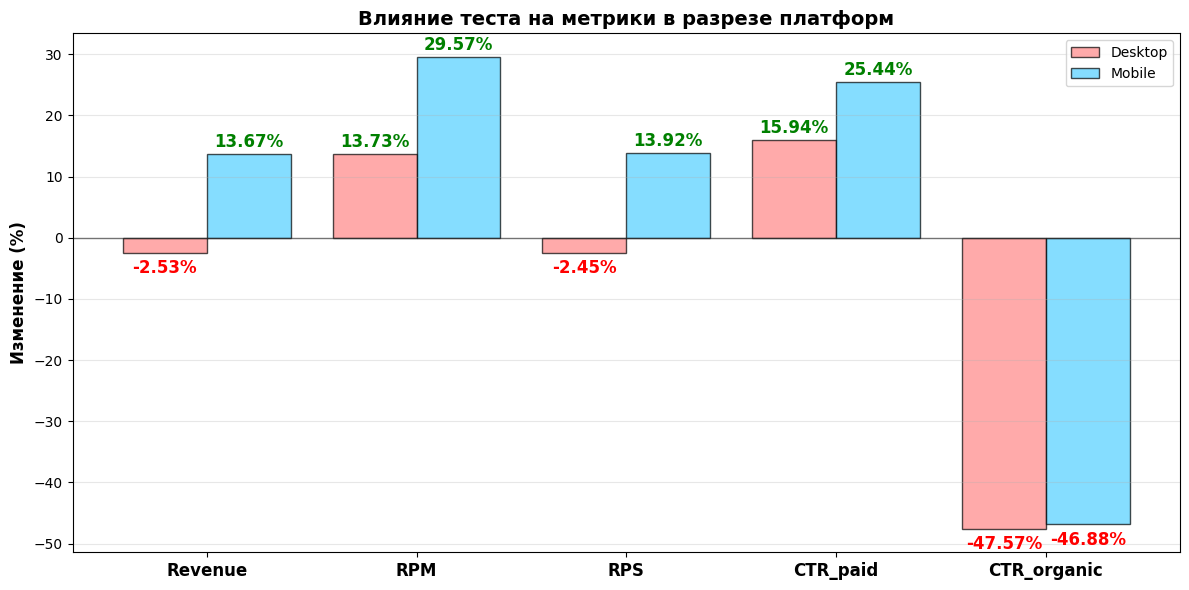

In [8]:
# Стрроим график для анализа группы В к А по каждой платформе
platforms = ['Desktop', 'Mobile']
columns = ['revenue_change_%', 'RPM_change_%', 'RPS_change_%', 'CTR_paid_change_%', 'CTR_organic_change_%']
metrics = ['Revenue', 'RPM', 'RPS', 'CTR_paid', 'CTR_organic']
desktop_values = df_changes.iloc[0][columns].tolist() 
mobile_values = df_changes.iloc[1][columns].tolist() 

x = np.arange(len(metrics))
width = 0.40

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, desktop_values, width, label='Desktop', color='#ff8787', edgecolor='black', alpha=0.7)
bars2 = ax.bar(x + width/2, mobile_values, width, label='Mobile', color='#51cfff', edgecolor='black', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_ylabel('Изменение (%)', fontsize=12, fontweight='bold')
ax.set_title('Влияние теста на метрики в разрезе платформ', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Добавляем значения
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        color = 'green' if height > 0 else 'red'
        ax.text(bar.get_x() + bar.get_width()/2., height + (0.5 if height > 0 else -1),
                f'{height}%', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=12, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

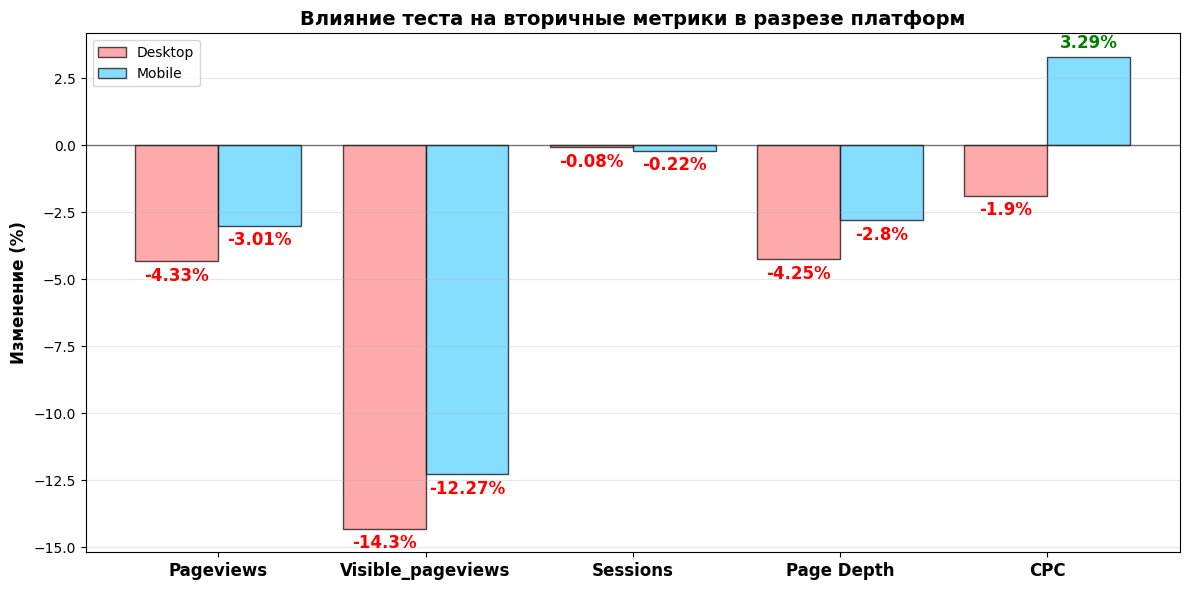

In [10]:
# График по 'Pageviews', 'Visible_pageviews', 'Sessions', 'Page Depth', 'CPC'
platforms = ['Desktop', 'Mobile']
columns = ['pageviews_change_%', 'visible_pageviews_change_%', 'sessions_change_%', 'Pages_Depth_change_%', 'CPC_change_%']
metrics = ['Pageviews', 'Visible_pageviews', 'Sessions', 'Page Depth', 'CPC']
desktop_values = df_changes.iloc[0][columns].tolist() 
mobile_values = df_changes.iloc[1][columns].tolist() 

x = np.arange(len(metrics))
width = 0.40

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, desktop_values, width, label='Desktop', color='#ff8787', edgecolor='black', alpha=0.7)
bars2 = ax.bar(x + width/2, mobile_values, width, label='Mobile', color='#51cfff', edgecolor='black', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_ylabel('Изменение (%)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_title('Влияние теста на вторичные метрики в разрезе платформ', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Добавляем значения
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        color = 'green' if height > 0 else 'red'
        ax.text(bar.get_x() + bar.get_width()/2., height + (0.2 if height > 0 else -0.2),
                f'{height}%', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=12, fontweight='bold', color=color)
        

plt.tight_layout()
plt.show()

In [15]:
# 'Desktop'
daily_Desktop = (df[df['platform'] == 'Desktop']
                .groupby(['date','group_name'])
                .agg(pageviews = ('pageviews', 'sum'),
                    visible = ('visible_pageviews', 'sum'),
                    session = ('sessions', 'sum'),
                    sponsord_clicks = ('sponsord_clicks', 'sum'),
                    organic_clicks = ('organic_clicks', 'sum'),
                    revenue = ('revenue', 'sum')
                    )
                .reset_index()
).sort_values(['group_name','date']).reset_index(drop=True)
# расчет  взвешенного среднего revenue
daily_Desktop['multiply'] = daily_Desktop['pageviews'] * daily_Desktop['revenue']
daily_Desktop['cum_multiply'] = daily_Desktop.groupby('group_name')['multiply'].cumsum()
daily_Desktop['cum_page'] = daily_Desktop.groupby('group_name')['pageviews'].cumsum()
daily_Desktop['cum_weighted_avg'] = daily_Desktop['cum_multiply'] / daily_Desktop['cum_page']
daily_Desktop['day'] = daily_Desktop.groupby('group_name').cumcount() + 1

# 'Mobile'
daily_Mobile = (df[df['platform'] == 'Mobile']
                .groupby(['date','group_name'])
                .agg(pageviews = ('pageviews', 'sum'),
                    visible = ('visible_pageviews', 'sum'),
                    session = ('sessions', 'sum'),
                    sponsord_clicks = ('sponsord_clicks', 'sum'),
                    organic_clicks = ('organic_clicks', 'sum'),
                    revenue = ('revenue', 'sum')
                    )
                .reset_index()
                .sort_values(['group_name','date']).reset_index(drop=True)
)
# расчет взвешенного среднего revenue
daily_Mobile['multiply'] = daily_Mobile['pageviews'] * daily_Mobile['revenue']
daily_Mobile['cum_multiply'] = daily_Mobile.groupby('group_name')['multiply'].cumsum()
daily_Mobile['cum_page'] = daily_Mobile.groupby('group_name')['pageviews'].cumsum()
daily_Mobile['cum_weighted_avg'] = daily_Mobile['cum_multiply'] / daily_Mobile['cum_page']
daily_Mobile['day'] = daily_Mobile.groupby('group_name').cumcount() + 1


In [16]:
daily_Mobile

,date,group_name,pageviews,visible,session,sponsord_clicks,organic_clicks,revenue,multiply,cum_multiply,cum_page,cum_weighted_avg,day
0,2019-03-01,A,152095,34582,86117,2048,7596,214.1184,3.256634e+07,3.256634e+07,152095,214.118400,1
1,2019-03-02,A,168165,38419,92172,2593,8573,214.3584,3.604758e+07,6.861392e+07,320260,214.244421,2
2,2019-03-03,A,177924,42269,96193,3004,9581,233.5202,4.154885e+07,1.101628e+08,498184,221.128672,3
3,2019-03-04,A,185987,44990,100999,2932,9862,270.7459,5.035522e+07,1.605180e+08,684171,234.616761,4
4,2019-03-06,A,163939,41632,112536,3033,8665,353.2843,5.791707e+07,2.184351e+08,848110,257.555104,5
5,2019-03-07,A,159580,38160,92680,2422,8507,215.8759,3.444948e+07,2.528845e+08,1007690,250.954694,6
6,2019-03-01,B,147280,30808,85598,2241,3542,251.6332,3.706054e+07,3.706054e+07,147280,251.633200,1
7,2019-03-02,B,163135,33245,92117,2920,4072,251.9522,4.110222e+07,7.816276e+07,310415,251.800847,2
8,2019-03-03,B,170695,36561,94676,3291,4518,278.3115,4.750638e+07,1.256691e+08,481110,261.206671,3
9,2019-03-04,B,180931,39333,100674,3234,4541,286.2418,5.179002e+07,1.774592e+08,662041,268.048590,4


In [114]:
Mobile_pivod = daily_Mobile.pivot(index=['day','date'], columns = 'group_name', values = 'cum_weighted_avg').reset_index()
Mobile_pivod.columns.name = None

Desktop_pivod = daily_Desktop.pivot(index=['day','date'], columns = 'group_name', values = 'cum_weighted_avg').reset_index()
Desktop_pivod.columns.name = None


А как насчет трендов?? 
воспользуюсь своими идеями, но кодом, частично написанным ИИ (работа с моделями)

Хотел расчитать линию тренда, но из-за того, что мало дней (6 дней, ведь 1 день мы удалили), тренд не показывает свою статистическую значимость, так как сильный разброс показателей прибыли изо дня в день (скачет вверх/вниз)
Прогнозы совсем получаются неточные.

Поэтому решил расчитать средневзвешенную выручку за прешедший период (кумулятивное средневзвешенное) по каждой группе в каждой страте. по ним попробовать построить тренд

In [112]:
Desktop_pivod

,day,date,A,B
0,1,2019-03-01,149.447600,142.914600
1,2,2019-03-02,151.913239,150.758434
2,3,2019-03-03,161.477003,150.715303
3,4,2019-03-04,180.148377,172.277602
4,5,2019-03-06,179.573754,176.247483
5,6,2019-03-07,181.526141,178.442200


                     Метрика Группа A Группа B
0           Текущее значение  181.526  178.442
1          Среднее за период  167.348  161.893
2             Тренд (в день)  +7.4870  +7.8762
3         Стандартная ошибка   1.3443   1.2607
4    95% дов. интервал (низ)   3.7547   4.3759
5   95% дов. интервал (верх)  11.2193  11.3765
6                         R²    0.886    0.907
7                    p-value   0.0051   0.0033
8  Статистическая значимость   Значим   Значим
ПРОВЕРКА РАЗНИЦЫ МЕЖДУ ГРУППАМИ
p-value разницы: 0.5476
Группы статистически НЕ РАЗЛИЧАЮТСЯ (нужно больше данных)

 Прогноз пересечения:
  Группа B догонит A через 13 дней
  Примерно 19.03.2019


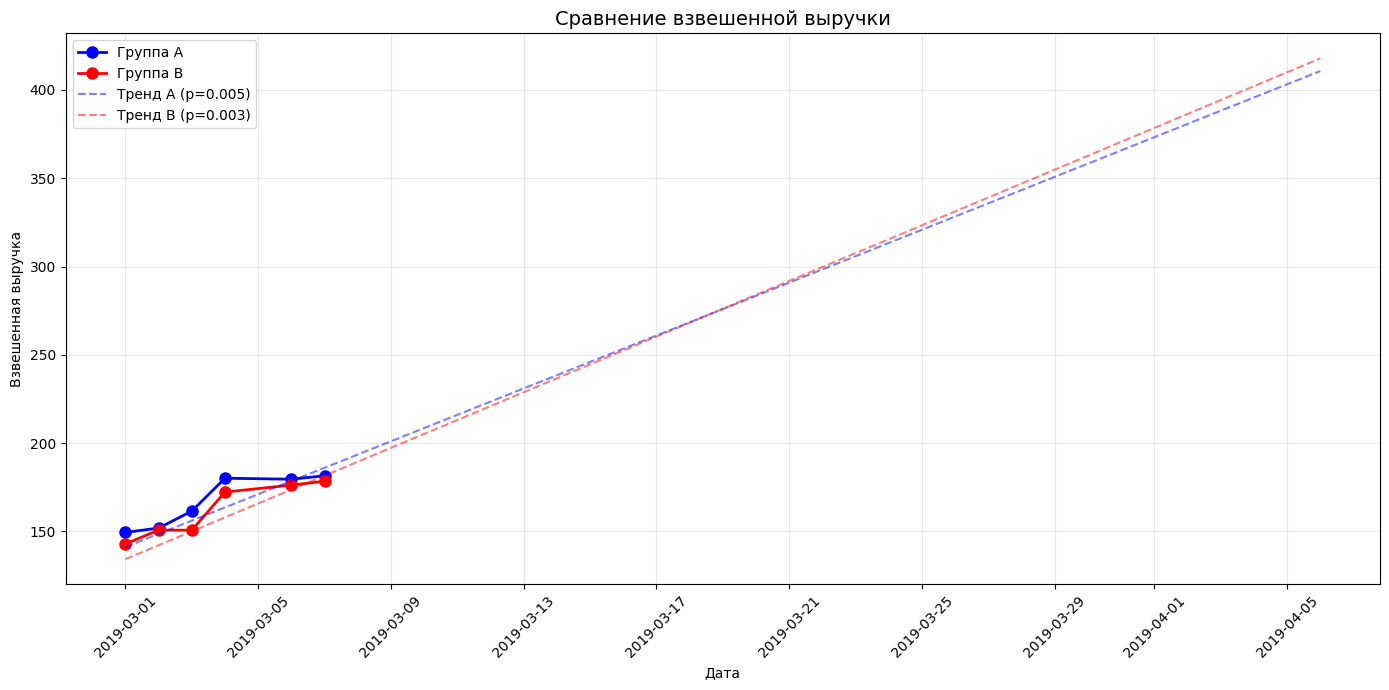

In [113]:
from sklearn.linear_model import LinearRegression

# Функция для расчета тренда с p-value 
def analyze_trend(x, y, group_name):
    # Линейная регрессия
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Предсказания и остатки
    y_pred = model.predict(x.reshape(-1, 1))
    residuals = y - y_pred
    
    # R²
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    # p-value через linregress
    slope_reg, intercept_reg, r_value, p_value, std_err = linregress(x, y)
    
    # Доверительный интервал для наклона
    t_critical = t.ppf(0.975, len(x)-2)  # 95% доверительный интервал
    ci_lower = slope - t_critical * std_err
    ci_upper = slope + t_critical * std_err
    
    return {
        'group': group_name,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'last_value': y[-1],
        'mean': np.mean(y)
    }

result_A = analyze_trend(Desktop_pivod['day'].values, Desktop_pivod['A'].values, 'A')
result_B = analyze_trend(Desktop_pivod['day'].values, Desktop_pivod['B'].values, 'B')

# Сводная таблица
comparison = pd.DataFrame({
    'Метрика': [
        'Текущее значение',
        'Среднее за период',
        'Тренд (в день)',
        'Стандартная ошибка',
        '95% дов. интервал (низ)',
        '95% дов. интервал (верх)',
        'R²',
        'p-value',
        'Статистическая значимость'
    ],
    'Группа A': [
        f"{result_A['last_value']:.3f}",
        f"{result_A['mean']:.3f}",
        f"{result_A['slope']:+.4f}",
        f"{result_A['std_err']:.4f}",
        f"{result_A['ci_lower']:.4f}",
        f"{result_A['ci_upper']:.4f}",
        f"{result_A['r_squared']:.3f}",
        f"{result_A['p_value']:.4f}",
        "Значим" if result_A['p_value'] < 0.05 else "Не значим"
    ],
    'Группа B': [
        f"{result_B['last_value']:.3f}",
        f"{result_B['mean']:.3f}",
        f"{result_B['slope']:+.4f}",
        f"{result_B['std_err']:.4f}",
        f"{result_B['ci_lower']:.4f}",
        f"{result_B['ci_upper']:.4f}",
        f"{result_B['r_squared']:.3f}",
        f"{result_B['p_value']:.4f}",
        "Значим" if result_B['p_value'] < 0.05 else "Не значим"
    ]
})
print(comparison)

# Проверка значимости разницы между группами
print("ПРОВЕРКА РАЗНИЦЫ МЕЖДУ ГРУППАМИ")

# t-тест для последних значений
t_stat, p_value_diff = ttest_ind(
    Desktop_pivod['A'].values, 
    Desktop_pivod['B'].values
)
print(f"p-value разницы: {p_value_diff:.4f}")
if p_value_diff < 0.05:
    print("Группы СТАТИСТИЧЕСКИ РАЗЛИЧАЮТСЯ (есть победитель)")
else:
    print("Группы статистически НЕ РАЗЛИЧАЮТСЯ (нужно больше данных)")

# Когда B догонит A?
if result_A['slope'] != result_B['slope']:
    days_to_catch = (result_B['intercept'] - result_A['intercept']) / (result_A['slope'] - result_B['slope'])
    days_from_today = days_to_catch - len(Desktop_pivod) + 1
    
    print(f"\n Прогноз пересечения:")
    if days_from_today > 0 and days_from_today < 365:
        catch_date = pd.to_datetime('2019-03-07') + pd.Timedelta(days=days_from_today)
        print(f"  Группа B догонит A через {days_from_today:.0f} дней")
        print(f"  Примерно {catch_date.strftime('%d.%m.%Y')}")
    elif days_from_today < 0:
        print(f"  Группа B уже обогнала A (если это возможно)")
    else:
        print(f"  Группа B НЕ догонит A в обозримом будущем")

# Визуализация
plt.figure(figsize=(14, 7))

# Точки
plt.plot(Desktop_pivod['date'], Desktop_pivod['A'], 'bo-', label='Группа A', linewidth=2, markersize=8)
plt.plot(Desktop_pivod['date'], Desktop_pivod['B'], 'ro-', label='Группа B', linewidth=2, markersize=8)

# Линии тренда
x_fit = np.linspace(0, len(Desktop_pivod)+30, 100)
plt.plot(Desktop_pivod['date'].min() + pd.to_timedelta(x_fit, unit='D'), 
         result_A['intercept'] + result_A['slope'] * x_fit,
         'b--', alpha=0.5, label=f'Тренд A (p={result_A["p_value"]:.3f})')
plt.plot(Desktop_pivod['date'].min() + pd.to_timedelta(x_fit, unit='D'), 
         result_B['intercept'] + result_B['slope'] * x_fit, 
         'r--', alpha=0.5, label=f'Тренд B (p={result_B["p_value"]:.3f})')

plt.title('Сравнение взвешенной выручки', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Взвешенная выручка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [115]:
Mobile_pivod

,day,date,A,B
0,1,2019-03-01,214.118400,251.633200
1,2,2019-03-02,214.244421,251.800847
2,3,2019-03-03,221.128672,261.206671
3,4,2019-03-04,234.616761,268.048590
4,5,2019-03-06,257.555104,288.217810
5,6,2019-03-07,250.954694,284.865516


                     Метрика Группа A Группа B
0           Текущее значение  250.955  284.866
1          Среднее за период  232.103  267.629
2             Тренд (в день)  +9.3600  +8.0644
3         Стандартная ошибка   1.8483   1.3665
4    95% дов. интервал (низ)   4.2283   4.2705
5   95% дов. интервал (верх)  14.4918  11.8583
6                         R²    0.865    0.897
7                    p-value   0.0072   0.0041
8  Статистическая значимость   Значим   Значим
ПРОВЕРКА РАЗНИЦЫ МЕЖДУ ГРУППАМИ
p-value разницы: 0.0055
Группы СТАТИСТИЧЕСКИ РАЗЛИЧАЮТСЯ 

 Прогноз пересечения:
  Группа А догонит В через 26 дней
  Примерно 01.04.2019


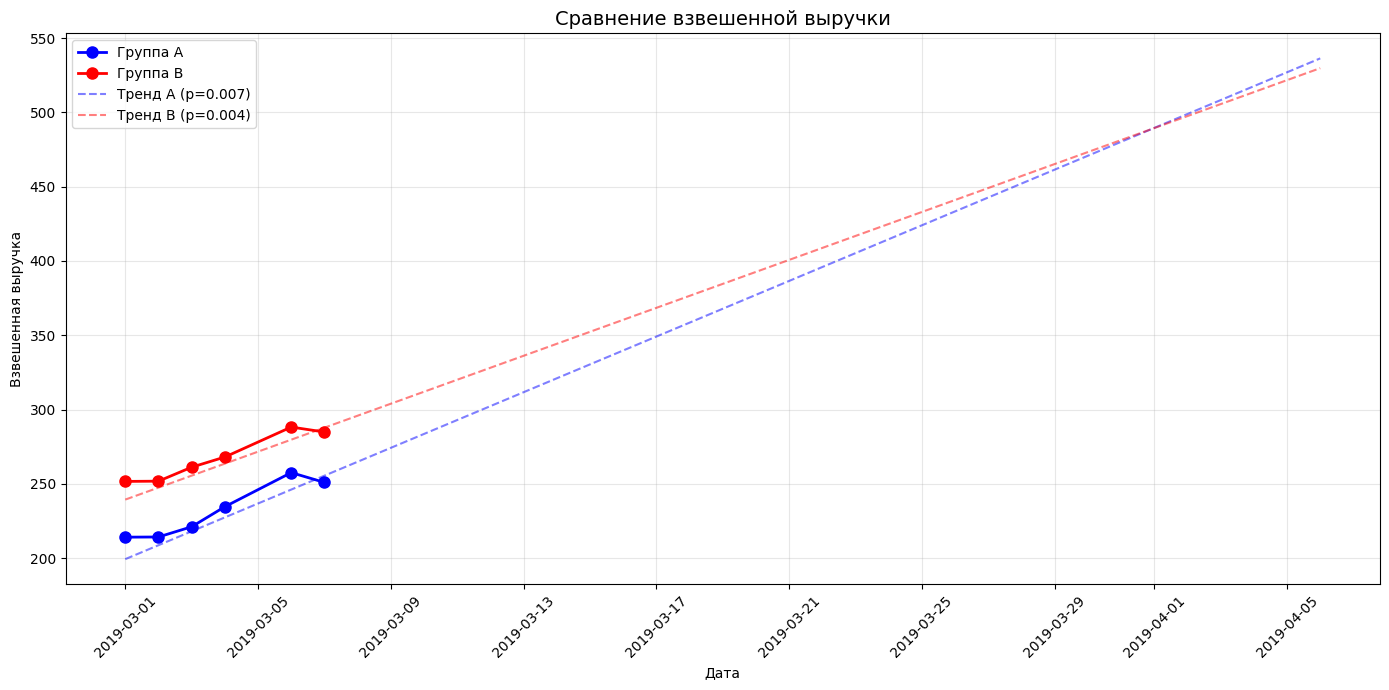

In [117]:
from sklearn.linear_model import LinearRegression

# Функция для расчета тренда с p-value 
def analyze_trend(x, y, group_name):
    # Линейная регрессия
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Предсказания и остатки
    y_pred = model.predict(x.reshape(-1, 1))
    residuals = y - y_pred
    
    # R²
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    # p-value через linregress
    slope_reg, intercept_reg, r_value, p_value, std_err = linregress(x, y)
    
    # Доверительный интервал для наклона
    t_critical = t.ppf(0.975, len(x)-2)  # 95% доверительный интервал
    ci_lower = slope - t_critical * std_err
    ci_upper = slope + t_critical * std_err
    
    return {
        'group': group_name,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'last_value': y[-1],
        'mean': np.mean(y)
    }

result_A = analyze_trend(Mobile_pivod['day'].values, Mobile_pivod['A'].values, 'A')
result_B = analyze_trend(Mobile_pivod['day'].values, Mobile_pivod['B'].values, 'B')

# Сводная таблица
comparison = pd.DataFrame({
    'Метрика': [
        'Текущее значение',
        'Среднее за период',
        'Тренд (в день)',
        'Стандартная ошибка',
        '95% дов. интервал (низ)',
        '95% дов. интервал (верх)',
        'R²',
        'p-value',
        'Статистическая значимость'
    ],
    'Группа A': [
        f"{result_A['last_value']:.3f}",
        f"{result_A['mean']:.3f}",
        f"{result_A['slope']:+.4f}",
        f"{result_A['std_err']:.4f}",
        f"{result_A['ci_lower']:.4f}",
        f"{result_A['ci_upper']:.4f}",
        f"{result_A['r_squared']:.3f}",
        f"{result_A['p_value']:.4f}",
        "Значим" if result_A['p_value'] < 0.05 else "Не значим"
    ],
    'Группа B': [
        f"{result_B['last_value']:.3f}",
        f"{result_B['mean']:.3f}",
        f"{result_B['slope']:+.4f}",
        f"{result_B['std_err']:.4f}",
        f"{result_B['ci_lower']:.4f}",
        f"{result_B['ci_upper']:.4f}",
        f"{result_B['r_squared']:.3f}",
        f"{result_B['p_value']:.4f}",
        "Значим" if result_B['p_value'] < 0.05 else "Не значим"
    ]
})
print(comparison)

# Проверка значимости разницы между группами
print("ПРОВЕРКА РАЗНИЦЫ МЕЖДУ ГРУППАМИ")

# t-тест для последних значений
t_stat, p_value_diff = ttest_ind(
    Mobile_pivod['A'].values, 
    Mobile_pivod['B'].values
)
print(f"p-value разницы: {p_value_diff:.4f}")
if p_value_diff < 0.05:
    print("Группы СТАТИСТИЧЕСКИ РАЗЛИЧАЮТСЯ ")
else:
    print("Группы статистически НЕ РАЗЛИЧАЮТСЯ (нужно больше данных)")

# Когда А догонит В?
if result_A['slope'] != result_B['slope']:
    days_to_catch = (result_B['intercept'] - result_A['intercept']) / (result_A['slope'] - result_B['slope'])
    days_from_today = days_to_catch - len(Mobile_pivod) + 1
    
    print(f"\n Прогноз пересечения:")
    if days_from_today > 0 and days_from_today < 365:
        catch_date = pd.to_datetime('2019-03-07') + pd.Timedelta(days=days_from_today)
        print(f"  Группа А догонит В через {days_from_today:.0f} дней")
        print(f"  Примерно {catch_date.strftime('%d.%m.%Y')}")
    elif days_from_today < 0:
        print(f"  Группа А уже обогнала В (если это возможно)")
    else:
        print(f"  Группа А НЕ догонит В в обозримом будущем")

# Визуализация
plt.figure(figsize=(14, 7))

# Точки
plt.plot(Mobile_pivod['date'], Mobile_pivod['A'], 'bo-', label='Группа A', linewidth=2, markersize=8)
plt.plot(Mobile_pivod['date'], Mobile_pivod['B'], 'ro-', label='Группа B', linewidth=2, markersize=8)

# Линии тренда
x_fit = np.linspace(0, len(Mobile_pivod)+30, 100)
plt.plot(Mobile_pivod['date'].min() + pd.to_timedelta(x_fit, unit='D'), 
         result_A['intercept'] + result_A['slope'] * x_fit,
         'b--', alpha=0.5, label=f'Тренд A (p={result_A["p_value"]:.3f})')
plt.plot(Mobile_pivod['date'].min() + pd.to_timedelta(x_fit, unit='D'), 
         result_B['intercept'] + result_B['slope'] * x_fit, 
         'r--', alpha=0.5, label=f'Тренд B (p={result_B["p_value"]:.3f})')

plt.title('Сравнение взвешенной выручки', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Взвешенная выручка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()